# CS2006: Advanced Programming Projects

## Practical P2: Data analysis and visualisation Python

### Loading the data

In [503]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns
from ipywidgets import interact, interactive_output, VBox, fixed
import numpy as np


In [504]:
df = pd.read_csv("../data/publicmicrodatateachingsample.csv")

## Set up chart labels

### Initialise labels

In [505]:
social_grade_labels = {
    -8.0: "Does not apply",
     1.0: "AB Higher and intermediate managerial/administrative/professional occupations",
	 2.0: "C1 Supervisory, clerical and junior managerial/administrative/professional occupations",
	 3.0: "C2 Skilled manual occupations",
	 4.0: "DE Semi-skilled and unskilled manual occupations; unemployed and lowest grade" 
} 

country_of_birth_labels = {
    -8.0: "Does not apply",
     1.0: "United Kingdom",
     2.0: "Other countries"
}

economic_activity_labels = {
    -8.0: "Does not apply",
	 1.0: "Economically active (excluding full-time students): In employment: Employee",
	 2.0: "Economically active (excluding full-time students): In employment: Self-employed",
	 3.0: "Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained",
	 4.0: "Economically active and a full-time student",
	 5.0: "Economically inactive: Retired",
	 6.0: "Economically inactive: Student",
	 7.0: "Economically inactive: Looking after home or family",
	 8.0: "Economically inactive: Long-term sick or disabled",
	 9.0: "Economically inactive: Other"
}

ethinic_groups_labels = {
    -8.0: "Does not apply",
     1.0: "Asian, Asian British or Asian Welsh",
	 2.0: "Black, Black British, Black Welsh, Caribbean or African",
	 3.0: "Mixed or Multiple ethnic groups",
	 4.0: "White",
	 5.0: "Other ethnic group",
}

health_labels = {
    -8.0: "Does not apply",
     1.0: "Very good health",
     2.0: "Good health",
     3.0: "Fair health",
     4.0: "Bad health",
     5.0: "Very bad health"
}

family_labels = {
    -8.0: "Does not apply",
	 1.0: "One-person household",
	 2.0: "Married or civil partnership couple household",
	 3.0: "Cohabiting couple household",
	 4.0: "Lone parent household",
	 5.0: "Multi-person household",
}

hours_labels = {
    -8.0: "Does not apply",
    1.0: "15 hours or less",
    2.0: "16 to 30",
    3.0: "31 to 48",
    4.0: "49 or more"
}

education_labels = {
    -8.0: "Does not apply",
     1.0: "Student",
     2.0: "Not a student",
}

industry_labels = {
    -8.0: "Does not apply",
    1.0: "A Agriculture, forestry and fishing",
	2.0: "C Manufacturing",
	3.0: "B, D, E Energy and water",
	4.0: "F Construction",
	5.0: "G, I Distribution, hotels and restaurants",
	6.0: "H, J Transport and communication",
	7.0: "K, L, M, N Financial, real estate, professional and administrative activities",
	8.0: "O, P, Q Public administration, education and health",
	9.0: "R, S, T, U Other"
}

london_labels = {
    -8.0: "Does not apply",
    "E13000001": "Inner London",
    "E13000002": "Outer London"
}

partner_labels = {
    -8.0: "Does not apply",
     1.0: "Never married and never registered a civil partnership",
     2.0: "Married or in a registered civil partnership",
     3.0: "Separated, but still legally married or still legally in a civil partnership",
     4.0: "Divorced or civil partnership dissolved",
     5.0: "Widowed or surviving civil partnership partner"
}

occupation_labels = {
    -8.0: "Does not apply",
	 1.0: "Managers, directors and senior officials",
	 2.0: "Professional occupations",
	 3.0: "Associate professional and technical occupations",
	 4.0: "Administrative and secretarial occupations",
	 5.0: "Skilled trades occupations",
	 6.0: "Caring, leisure and other service occupations",
	 7.0: "Sales and customer service occupations",
	 8.0: "Process, plant and machine operatives",
	 9.0: "Elementary occupations"
}

region_labels = {
    "E12000001":  "North East",
	"E12000002":  "North West",
	"E12000003":  "Yorkshire and The Humber",
	"E12000004":  "East Midlands",
	"E12000005":  "West Midlands",
	"E12000006":  "East of England",
	"E12000007":  "London",
	"E12000008":  "South East",
	"E12000009":  "South West",
	"W92000004":  "Wales",
	"N99999999":  "Does not apply: Northern Ireland",
	"S99999999":  "Does not apply: Scotland"
}

religion_labels = {
    -8.0: "Does not apply",
	 1.0: "No religion",
	 2.0: "Christian",
	 3.0: "Buddhist",
	 4.0: "Hindu",
	 5.0: "Jewish",
	 6.0: "Muslim",
	 7.0: "Sikh",
	 8.0: "Other religion",
	 9.0: "Not answered"
}

residence_labels = {
    1.0: "Lives in a household",
    2.0: "Lives in a communal establishment"
}

age_labels = {
    -8.0: "Does not apply",
     1.0: "Aged 15 years and under",
     2.0: "Aged 16 to 24 years",
     3.0: "Aged 25 to 34 years",
     4.0: "Aged 35 to 44 years",
     5.0: "Aged 45 to 54 years",
     6.0: "Aged 55 to 64 years",
     7.0: "Aged 65 years and over"
}

sex_labels = {
    -8.0: "Does not apply",
     1.0: "Female",
     2.0: "Male"
}

usual_student_labels = {
    -8.0: "Does not apply",
     1.0: "Is a usual resident",
     2.0: "Is a student living at an alternative address in term time",
     3.0: "Is a non-UK-born short-term resident, staying 3 to 12 months"
}

### Initialise table order

In [506]:
occupation_order = ["Does not apply", "Managers, directors and senior officials", "Professional occupations", "Associate professional and technical occupations", "Administrative and secretarial occupations", "Skilled trades occupations", "Caring, leisure and other service occupations", "Sales and customer service occupations", "Process, plant and machine operatives", "Elementary occupations"]
social_grade_order = ["Does not apply", "AB Higher and intermediate managerial/administrative/professional occupations", "C1 Supervisory, clerical and junior managerial/administrative/professional occupations", "C2 Skilled manual occupations", "DE Semi-skilled and unskilled manual occupations; unemployed and lowest grade" ]
country_of_birth_order = ["Does not apply", "United Kingdom", "Other countries"]
economic_activity_order = ["Does not apply", "Economically active (excluding full-time students): In employment: Employee", "Economically active (excluding full-time students): In employment: Self-employed", "Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained", "Economically active and a full-time student", "Economically inactive: Retired", "Economically inactive: Student", "Economically inactive: Looking after home or family", "Economically inactive: Long-term sick or disabled", "Economically inactive: Other"]
ethinic_groups_order = ["Does not apply", "Asian, Asian British or Asian Welsh", "Black, Black British, Black Welsh, Caribbean or African", "Mixed or"]
sex_order = ["Does not apply", "Female", "Male"]
health_order = ["Does not apply", "Very good health", "Good health", "Fair health", "Bad health", "Very bad health"]
family_order = ["Does not apply", "One-person household", "Married or civil partnership couple household", "Cohabiting couple household", "Lone parent household", "Multi-person household"]
hours_order = ["Does not apply", "15 hours or less", "16 to 30", "31 to 48", "49 or more"]
education_order = ["Does not apply", "Student", "Not a student"]
region_order = ["North East", "North West", "Yorkshire and The Humber", "East Midlands", "West Midlands", "East of England", "London", "South East", "South West", "Wales", "Does not apply: Northern Ireland", "Does not apply: Scotland"]
usual_student_order = ["Does not apply", "Is a usual resident", "Is a student living at an alternative address in term time", "Is a non-UK-born short-term resident, staying 3 to 12 months"]
partner_order = ["Does not apply", "Never married and never registered a civil partnership", "Married or in a registered civil partnership", "Separated, but still legally married or still legally in a civil partnership", "Divorced or civil partnership dissolved", "Widowed or surviving civil partnership partner"]
london_order = ["Does not apply", "Inner London", "Outer London"]
industry_order = ["Does not apply", "A Agriculture, forestry and fishing", "C Manufacturing", "B, D, E Energy and water", "F Construction", "G, I Distribution, hotels and restaurants", "H, J Transport and communication", "K, L, M, N Financial, real estate, professional and administrative activities", "O, P, Q Public administration, education and health", "R, S, T, U Other"]
religion_order = ["Does not apply", "No religion", "Christian", "Buddhist", "Hindu", "Jewish", "Muslim", "Sikh", "Other religion", "Not answered"]
residence_order = ["Does not apply", "Lives in a household", "Lives in a communal establishment"]
age_order = ["Does not apply", "Aged 15 years and under", "Aged 16 to 24 years", "Aged 25 to 34 years", "Aged 35 to 44 years", "Aged 45 to 54 years", "Aged 55 to 64 years", "Aged 65 years and over"]



### Initialise label and order maps

In [507]:
label_map = {
    "approx_social_grade": social_grade_labels,
    "country_of_birth_3a": country_of_birth_labels,
    "economic_activity_status_10m": economic_activity_labels,
    "ethnic_group_tb_6a": ethinic_groups_labels,
    "health_in_general": health_labels,
    "hh_families_type_6a": family_labels,
    "hours_per_week_worked": hours_labels,
    "in_full_time_education": education_labels,
    "industry_10a": industry_labels,
    "iol22cd": london_labels,
    "legal_partnership_status_6a": partner_labels,
    "occupation_10a": occupation_labels,
    "region": region_labels,
    "religion_tb": religion_labels,
    "residence_type": residence_labels,
    "resident_age_7d": age_labels,
    "sex": sex_labels,
    "usual_short_student": usual_student_labels
}

order_map = {
    "approx_social_grade": social_grade_order,
    "country_of_birth_3a": country_of_birth_order,
    "economic_activity_status_10m": economic_activity_order,
    "ethnic_group_tb_6a": ethinic_groups_order,
    "health_in_general": health_order,
    "hh_families_type_6a": family_order,
    "hours_per_week_worked": hours_order,
    "in_full_time_education": education_order,
    "industry_10a": industry_order,
    "iol22cd": london_order,
    "legal_partnership_status_6a": partner_order,
    "occupation_10a": occupation_order,
    "region": region_order,
    "religion_tb": religion_order,
    "residence_type": residence_order,
    "resident_age_7d": age_order,
    "sex": sex_order,
    "usual_short_student": usual_student_order
}

name_map = {
    "approx_social_grade": "Social Grade",
    "country_of_birth_3a": "Country of Birth",
    "economic_activity_status_10m": "Economic Activity Status",
    "ethnic_group_tb_6a": "Ethnic Group",
    "health_in_general": "Health",
    "hh_families_type_6a": "Family",
    "hours_per_week_worked": "Hours Worked",
    "in_full_time_education": "Education",
    "iol22cd": "London",
    "legal_partnership_status_6a": "Partner",
    "region": "Region",
    "occupation_10a": "Occupation",
    "religion_tb": "Religion",
    "residence_type": "Residence",
    "resident_age_7d": "Age",
    "sex": "Sex",
    "usual_short_student": "Usual Student",
    "hours_per_week_worked": "Hours worked",
    "industry_10a": "Industry"          
}
    

## Draw bar charts

### Initialise bar chart functions

In [508]:
def draw_bar_chart(column, labels, title, xlabel):
    counts = df.groupby(column)[column].count()
    counts.index = counts.index.map(labels)
    counts.plot(kind='bar')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Residents")

def plot_chart(value):
    if value == "Social Grade Distributions":
        draw_bar_chart("approx_social_grade", social_grade_labels, "Social Grade Distributions", "Social Grade")
    elif value == "Country of Birth Distributions":
        draw_bar_chart("country_of_birth_3a", country_of_birth_labels, "Country of Birth Distributions", "Country of Birth")
    elif value == "Economic Activity Distributions":
        draw_bar_chart("economic_activity_status_10m", economic_activity_labels, "Economic Activity Distributions", "Economic Activity")   
    elif value == "Ethnic Groups Distributions":
        draw_bar_chart("ethnic_group_tb_6a", ethinic_groups_labels, "Ethnic Groups Distributions", "Ethnic Group")
    elif value == "Health Distributions":
        draw_bar_chart("health_in_general", health_labels, "Health Distributions", "Health")
    elif value == "Family Distributions":
        draw_bar_chart("hh_families_type_6a", family_labels, "Family Distributions", "Family Type")
    elif value == "Hours Worked Distributions":
        draw_bar_chart("hours_per_week_worked", hours_labels, "Hours Worked Distributions", "Hours Worked")
    elif value == "Education Distributions":
        draw_bar_chart("in_full_time_education", education_labels, "Education Distributions", "Education Status")
    elif value == "Industry Distributions":
        draw_bar_chart("industry_10a", industry_labels, "Industry Distributions", "Industry")
    elif value == "London Borough Distributions":
        draw_bar_chart("iol22cd", london_labels, "London Borough Distributions", "London Borough")
    elif value == "Partner Distributions":
        draw_bar_chart("legal_partnership_status_6a", partner_labels, "Partner Distributions", "Partnership Status")
    elif value == "Occupation Distributions":
        draw_bar_chart("occupation_10a", occupation_labels, "Occupation Distributions", "Occupation")
    elif value == "Region Distributions":
        draw_bar_chart("region", region_labels, "Region Distributions", "Region")
    elif value == "Religion Distributions":
        draw_bar_chart("religion_tb", religion_labels, "Religion Distributions", "Religion")
    elif value == "Residence Distributions":
        draw_bar_chart("residence_type", residence_labels, "Residence Distributions", "Residence Type")
    elif value == "Age Distributions":
        draw_bar_chart("resident_age_7d", age_labels, "Age Distributions", "Age")
    elif value == "Sex Distributions":
        draw_bar_chart("sex", sex_labels, "Sex Distributions", "Sex")
    elif value == "Usual Student Distributions":
        draw_bar_chart("usual_short_student", usual_student_labels, "Usual Student Distributions", "Usual Student Status")

### Bar charts for basic requirements

In [509]:
bar_chart_selection = widgets.Dropdown(
    options = ["Social Grade Distributions", "Country of Birth Distributions", "Economic Activity Distributions",
               "Ethnic Groups Distributions", "Health Distributions", "Family Distributions",
               "Hours Worked Distributions", "Education Distributions", "Industry Distributions",
               "London Borough Distributions", "Partner Distributions", "Occupation Distributions",
               "Region Distributions", "Religion Distributions", "Residence Distributions",
               "Age Distributions", "Sex Distributions", "Usual Student Distributions"],
    value = "Age Distributions",
    description = "Chart to display: ",
    style = {'description_width': 'initial'}
)


out = interactive_output(plot_chart, {'value': bar_chart_selection})
display(VBox([bar_chart_selection, out]))

# Easy requirements

### Initialise pie chart functions

In [510]:
def draw_pie_chart(column, labels, title):
    counts = df.groupby(column)[column].count()
    counts.index = counts.index.map(labels)
    counts.plot(kind='pie', autopct='%1.1f%%')

    plt.title(title)
    plt.ylabel("")

def plot_pie_chart(value):
    if value == "Social Grade Distributions":
        draw_pie_chart("approx_social_grade", social_grade_labels, "Social Grade Distributions")
    elif value == "Country of Birth Distributions":
        draw_pie_chart("country_of_birth_3a", country_of_birth_labels, "Country of Birth Distributions")
    elif value == "Economic Activity Distributions":
        draw_pie_chart("economic_activity_status_10m", economic_activity_labels, "Economic Activity Distributions")
    elif value == "Ethic Groups Distributions":
        draw_pie_chart("ethnic_group_tb_6a", ethinic_groups_labels, "Ethnic Groups Distributions")
    elif value == "Health Distributions":
        draw_pie_chart("health_in_general", health_labels, "Health Distributions")
    elif value == "Family Distributions":
        draw_pie_chart("hh_families_type_6a", family_labels, "Family Distributions")
    elif value == "Hours Worked Distributions":
        draw_pie_chart("hours_per_week_worked", hours_labels, "Hours Worked Distributions")
    elif value == "Education Distributions":
        draw_pie_chart("in_full_time_education", education_labels, "Education Distributions")
    elif value == "Industry Distributions":
        draw_pie_chart("industry_10a", industry_labels, "Industry Distributions")
    elif value == "London Borough Distributions":
        draw_pie_chart("iol22cd", london_labels, "London Borough Distributions")
    elif value == "Partner Distributions":
        draw_pie_chart("legal_partnership_status_6a", partner_labels, "Partner Distributions")
    elif value == "Occupation Distributions":
        draw_pie_chart("occupation_10a", occupation_labels, "Occupation Distributions")
    elif value == "Region Distributions":
        draw_pie_chart("region", region_labels, "Region Distributions")
    elif value == "Religion Distributions":
        draw_pie_chart("religion_tb", religion_labels, "Religion Distributions")
    elif value == "Residence Distributions":
        draw_pie_chart("residence_type", residence_labels, "Residence Distributions")
    elif value == "Age Distributions":
        draw_pie_chart("resident_age_7d", age_labels, "Age Distributions")
    elif value == "Sex Distributions":
        draw_pie_chart("sex", sex_labels, "Sex Distributions")
    elif value == "Usual Student Distributions":
        draw_pie_chart("usual_short_student", usual_student_labels, "Usual Student Distributions")

### Pie Charts drawn

In [511]:
pie_chart_selection = widgets.Dropdown(
    options = ["Social Grade Distributions", "Country of Birth Distributions", "Economic Activity Distributions",
               "Ethic Groups Distributions", "Health Distributions", "Family Distributions",
               "Hours Worked Distributions", "Education Distributions", "Industry Distributions",
               "London Borough Distributions", "Partner Distributions", "Occupation Distributions",
               "Region Distributions", "Religion Distributions", "Residence Distributions",
               "Age Distributions", "Sex Distributions", "Usual Student Distributions"],
    description = "Chart to display: ",
    style = {'description_width': 'initial'}
)




out = interactive_output(plot_pie_chart, {'value': pie_chart_selection})
display(VBox([pie_chart_selection, out]))



# MEDIUM REQUIRMENTS 


## Group By tables for Hours Worked Vs Industry and Occupation Vs Social Grade

### 1. Number of records by hours by week and industry

In [512]:
def draw_table(variable1, variable2):
    df2 = df.copy()

    label1 = label_map[variable1]
    label2 = label_map[variable2]
    order1 = order_map[variable1]
    order2 = order_map[variable2]

    df2[variable1] = df2[variable1].map(label1)
    df2[variable2] = df2[variable2].map(label2)

    df2[variable1] = pd.Categorical(df2[variable1], categories=order1, ordered=True)
    df2[variable2] = pd.Categorical(df2[variable2], categories=order2, ordered=True)

    table = pd.crosstab(
        df2[variable1],
        df2[variable2],
        margins=True,
        margins_name="Total"
    )

    table.index.name = name_map[variable1]
    table.columns.name = name_map[variable2]
    
    display(table)



In [513]:
table_selection1 = widgets.Dropdown(
    options = [
        ("Social Grade",      "approx_social_grade"),
        ("Country of Birth",  "country_of_birth_3a"),
        ("Economic Activity", "economic_activity_status_10m"),
        ("Ethnic Group",      "ethnic_group_tb_6a"),
        ("Health",            "health_in_general"),
        ("Family",            "hh_families_type_6a"),
        ("Hours Worked",      "hours_per_week_worked"),
        ("Education",         "in_full_time_education"),
        ("London",            "iol22cd"),
        ("Partner",           "legal_partnership_status_6a"),
        ("Region",            "region"),
        ("Occupation",        "occupation_10a"),
        ("Religion",          "religion_tb"),
        ("Residence",         "residence_type"),
        ("Age",               "resident_age_7d"),
        ("Sex",               "sex"),
        ("Usual Student",     "usual_short_student"),
        ("Hours worked",      "hours_per_week_worked"),
        ("Industry",          "industry_10a"),
    ],
    value = "hours_per_week_worked",
    description = "Table to display: ",
    style = {'description_width': 'initial'}
)
table_selection2 = widgets.Dropdown(
    options = table_selection1.options,
    value = "industry_10a",
    description = "Table to display: ",
    style = {'description_width': 'initial'}
)


out = interactive_output(draw_table, {
    'variable1':        table_selection1,
    'variable2':        table_selection2
})

display(VBox([table_selection1, table_selection2, out]))

### 2. Number of records by occupation and approximate social grade

### Extra addition to the above - Heatmaps for both tables

#### Heatmap for Hours Worked vs Industry

In [514]:
def draw_heatmap(variable1, variable2, colour):
    df2 = df.copy()

    label1 = label_map[variable1]
    label2 = label_map[variable2]
    order1 = order_map[variable1]
    order2 = order_map[variable2]

    df2[variable1] = df2[variable1].map(label1)
    df2[variable2] = df2[variable2].map(label2)

    df2[variable1] = pd.Categorical(df2[variable1], categories=order1, ordered=True)
    df2[variable2] = pd.Categorical(df2[variable2], categories=order2, ordered=True)


    plt.figure(figsize=(12, 6))
    sns.heatmap(
        pd.crosstab(df2[variable1], df2[variable2]),
        annot=True, fmt='d', cmap=colour, cbar=False
    )
    plt.title(name_map[variable1] + " vs " + name_map[variable2])
    plt.ylabel(name_map[variable1])
    plt.xlabel(name_map[variable2])

In [515]:

colour_selection = widgets.Dropdown(
    options = ["Blues", "Greens", "Reds", "Purples", "Oranges"],
    description = "Colour scheme: ",
    style = {'description_width': 'initial'}
)

out = interactive_output(draw_heatmap, {
    'variable1':        table_selection1,
    'variable2':        table_selection2,
    'colour':           colour_selection
})

display(VBox([table_selection1, table_selection2, colour_selection, out]))

#### Heatmap for Occupation vs Social grade

In [516]:
# Function to update the heatmap for Hours Worked vs Industry
def update_hours_industry_heatmap(min_hours, max_hours):
    # Filter the dataframe based on the selected range of hours worked
    filtered_df = df[(df['hours_per_week_worked'] >= min_hours) & 
                     (df['hours_per_week_worked'] <= max_hours)]
    
    # Create the heatmap for the selected range of hours worked vs industry
    plt.figure(figsize=(12, 6))
    heatmap_data = pd.crosstab(filtered_df['hours_per_week_worked'], filtered_df['industry_10a'])
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Hours Worked vs Industry (Range: {min_hours}-{max_hours} hours)')
    plt.show()

# Function to update the heatmap for Occupation vs Social Grade
def update_occupation_social_grade_heatmap(selected_occupation):
    # Filter the dataframe based on the selected occupation
    filtered_df = df[df['occupation_10a'] == selected_occupation]
    
    # Create the heatmap for the selected occupation vs social grade
    plt.figure(figsize=(12, 6))
    heatmap_data = pd.crosstab(filtered_df['occupation_10a'], filtered_df['approx_social_grade'])
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Occupation vs Social Grade for: {selected_occupation}')
    plt.show()

# Create the widgets for the interaction

# Widget for selecting hours worked range
min_hours_slider = widgets.IntSlider(
    value=df['hours_per_week_worked'].min(),
    min=df['hours_per_week_worked'].min(),
    max=df['hours_per_week_worked'].max(),
    step=1,
    description='Min Hours Worked:',
    continuous_update=False
)

max_hours_slider = widgets.IntSlider(
    value=df['hours_per_week_worked'].max(),
    min=df['hours_per_week_worked'].min(),
    max=df['hours_per_week_worked'].max(),
    step=1,
    description='Max Hours Worked:',
    continuous_update=False
)

# Widget for selecting occupation
occupation_dropdown = widgets.Dropdown(
    options=df['occupation_10a'].unique(),
    value=df['occupation_10a'].mode()[0],
    description='Occupation:',
    disabled=False
)

# Link the widgets to the update functions
interact(update_hours_industry_heatmap, min_hours=min_hours_slider, max_hours=max_hours_slider)
interact(update_occupation_social_grade_heatmap, selected_occupation=occupation_dropdown)

interactive(children=(IntSlider(value=-8, continuous_update=False, description='Min Hours Worked:', max=4, min…

interactive(children=(Dropdown(description='Occupation:', index=6, options=(np.int64(5), np.int64(2), np.int64…

<function __main__.update_occupation_social_grade_heatmap(selected_occupation)>

## Medium Requirments 2
## Ecomomic Activitiy Analysis

In [ ]:
def draw_economic_bar_chart(column):
    df2 = df.copy()

    label = label_map[column]
    xlabel = name_map[column]

    economic_active = df2[df2['economic_activity_status_10m'].isin([1, 2, 3, 4])]  # Active status codes 1,2,3,4
    economic_inactive = df2[df2['economic_activity_status_10m'].isin([5, 6, 7, 8, 9])]  # Inactive status codes 5, 6, 7, 8,9

    active_by_age = economic_active.groupby(column)[column].count()
    inactive_by_age = economic_inactive.groupby(column)[column].count()

    active_by_age.index = active_by_age.index.map(label)
    inactive_by_age.index = inactive_by_age.index.map(label)


    x = np.arange(len(active_by_age.index)) 
    w = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(2*x + w/2, active_by_age.values, w,  label='Active', alpha=0.7)
    ax.bar(2*x - w/2, inactive_by_age.values, w, label='Inactive', alpha=0.7)
    plt.title('Economically Active vs Inactive People by ' + xlabel)
    plt.xticks(2*x, active_by_age.index, rotation=90)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.show()

In [518]:
# 1. Economically active people by age


# draw_economic_bar_chart("resident_age_7d", age_labels, "Age Group")

bar_selection = widgets.Dropdown(
    options = [
        ("Age",     "resident_age_7d"),
        ("Health",  "health_in_general"),
        ("Region",  "region"),
        ("Social Grade", "approx_social_grade")],
    value = "resident_age_7d",
    description = "Bar to display: ",
    style = {'description_width': 'initial'}
)

out = interactive_output(draw_economic_bar_chart, {
    'column':        bar_selection
})

display(VBox([bar_selection, out]))

In [519]:

# Function to update the plot for Economically Active People by Age Group
def update_economic_activity_plot(min_age, max_age):
    # Filter the dataframe based on the selected age range
    economic_active = df[df['economic_activity_status_10m'].isin([1, 2, 3, 4, 5, 6, 7])]  # Active status codes 1,2,3,4,5,6,7
    filtered_df = economic_active[(economic_active['resident_age_7d'] >= min_age) & 
                                  (economic_active['resident_age_7d'] <= max_age)]
    
    # Count economically active people by age group
    active_by_age = filtered_df.groupby('resident_age_7d')['resident_age_7d'].count()

    # Plot the updated data
    plt.figure(figsize=(10, 6))
    active_by_age.plot(kind='bar', color='skyblue')
    plt.title(f'Economically Active People by Age Group (Age: {min_age} - {max_age})')
    plt.xlabel('Age Group')
    plt.ylabel('Count')
    plt.show()

# Create the widgets for the interaction

# Slider for selecting the minimum age
min_age_slider = widgets.IntSlider(
    value=df['resident_age_7d'].min(),
    min=df['resident_age_7d'].min(),
    max=df['resident_age_7d'].max(),
    step=1,
    description='Min Age:',
    continuous_update=False
)

# Slider for selecting the maximum age
max_age_slider = widgets.IntSlider(
    value=df['resident_age_7d'].max(),
    min=df['resident_age_7d'].min(),
    max=df['resident_age_7d'].max(),
    step=1,
    description='Max Age:',
    continuous_update=False
)

# Link the widgets to the update function
interact(update_economic_activity_plot, min_age=min_age_slider, max_age=max_age_slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='Min Age:', max=7, min=1), IntSl…

<function __main__.update_economic_activity_plot(min_age, max_age)>

\Ecnomically inactive people by health status:


health_in_general
1    6043
2    8171
3    9263
4    8849
5    3520
Name: health_in_general, dtype: int64

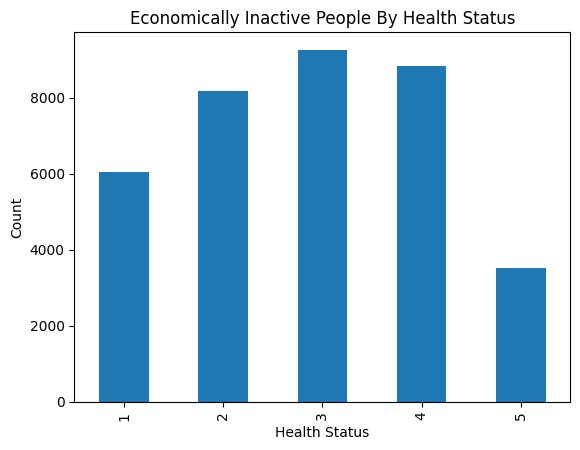

interactive(children=(Dropdown(description='Health Status:', options=(np.int64(1), np.int64(2), np.int64(3), n…

<function __main__.update_inactive_health_plot(selected_health)>

In [520]:
# 2. Economically inactive poeple by health status
economic_inactive = df[df['economic_activity_status_10m'].isin([8,9])] # Inactive status code 8,9
inactive_by_health = economic_inactive.groupby('health_in_general')['health_in_general'].count()

print("\Ecnomically inactive people by health status:")
display(inactive_by_health)

# Plot
inactive_by_health.plot(kind = 'bar', title = 'Economically Inactive People By Health Status')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.show()




# Function to update the plot for Economically Inactive People by Health Status
def update_inactive_health_plot(selected_health):
    # Clear the current plot
    plt.clf()
    
    # Filter the dataframe for economically inactive people (status codes 8, 9)
    economic_inactive = df[df['economic_activity_status_10m'].isin([8, 9])]
    
    # Filter the data based on the selected health status
    filtered_inactive = economic_inactive[economic_inactive['health_in_general'] == selected_health]
    
    # Count economically inactive people by health status
    inactive_by_health = filtered_inactive.groupby('health_in_general')['health_in_general'].count()

    # Plot the updated data
    plt.figure(figsize=(10, 6))
    inactive_by_health.plot(kind='bar', color='salmon')
    plt.title(f'Economically Inactive People by Health Status: {selected_health}')
    plt.xlabel('Health Status')
    plt.ylabel('Count')
    plt.show()

# Create the widget for selecting health status
health_dropdown_inactive = widgets.Dropdown(
    options=df['health_in_general'].unique(),  # Get unique health status values
    value=df['health_in_general'].mode()[0],   # Set initial value to the most common health status
    description='Health Status:',
    disabled=False
)

# Link the widget to the update function
interact(update_inactive_health_plot, selected_health=health_dropdown_inactive)